In [13]:
from types import NoneType
import numpy as np
import pandas as pd

import csv


data = {
    'Jan' : [],
    'Feb' : [],
    'Mar' : [],
    'Apr' : [],
    'May' : [],
    'Jun' : [],
    'Jul' : [],
    'Aug' : [],
    'Sep' : [],
    'Oct' : [],
    'Nov' : [],
    'Dec' : [],
}

f2p = {
    'Jan' : [],
    'Feb' : [],
    'Mar' : [],
    'Apr' : [],
    'May' : [],
    'Jun' : [],
    'Jul' : [],
    'Aug' : [],
    'Sep' : [],
    'Oct' : [],
    'Nov' : [],
    'Dec' : [],
}

#NOTE: no checks for overlap rn, high chance of duplicates
def dump_csv(filepath, date_index, price_index, player_count_index=-1, review_count_index=-1):
    with open(filepath, 'r', newline='', encoding='utf-8') as file:
        csv_reader = csv.reader(file)
        n = 0
        
        for row in csv_reader:
            # Skip header row
            if n == 0:
                n += 1
                continue
            # Skip if price not reported
            if row[price_index] == 'N/A':
                continue

            # Insert to table by month
            month = row[date_index]
            if month[0:3] not in data.keys():
                match month[5:7]:
                    case '01':
                        month = 'Jan'
                    case '02':
                        month = 'Feb'
                    case '03':
                        month = 'Mar'
                    case '04':
                        month = 'Apr'
                    case '05':
                        month = 'May'
                    case '06':
                        month = 'Jun'
                    case '07':
                        month = 'Jul'
                    case '08':
                        month = 'Aug'
                    case '09':
                        month = 'Sep'
                    case '10':
                        month = 'Oct'
                    case '11':
                        month = 'Nov'
                    case '12':
                        month = 'Dec'

            # Add a tuple of (player count, price) to the data table
            players = ""
            if player_count_index != -1:
                players = row[player_count_index]
                try:
                    players = int(players)
                except:
                    p = players.replace(',', "").split("\xa0..\xa0")
                    players = (int(p[0]) + int(p[1])) / 2
            else:
                players = row[review_count_index]

                if players == '':
                    continue

                # About 1 in 70 people review a game on average
                players = int(players) * 70


            price = row[price_index]
            if price[0:1] == '$':
                price = price[1:]
            if price == 'Free':
                price = 0.0
                            
            if month == '':
                continue

            t = (players, price)
            if price == 0.0:
                f2p[month[0:3]].append(t)
            else:
                data[month[0:3]].append(t)



# Steamspy
dump_csv('./data/SteamSpy.csv', 2, 3, player_count_index=5)
# Gamalyics
dump_csv('./data/GamalyicsFiltered.csv', 1, 3, player_count_index=2)
# Webscraped
dump_csv('./data/WebScrapeFiltered.csv', 3, 4, review_count_index=1)

 
# Sort the table rows
sorted_keys = sorted(data.keys(), key=lambda k: len(data[k]), reverse=True)

priced = pd.DataFrame()
free = pd.DataFrame()

for key in sorted_keys:
    priced[key] = pd.Series(data[key])

sorted_keys = sorted(f2p.keys(), key=lambda k: len(f2p[k]), reverse=True)

for key in sorted_keys:
    free[key] = pd.Series(f2p[key])

print(priced)
print(free)



# NOTE: Usage of data from the frame will almost certainly need to be in a for loop format due to the use of tuples
# NOTE: Most of the rows end with an arbitrary number of NaNs, these will need to be accounted for

                     Oct                  Sep                 Nov  \
0     (3500000.0, 19.99)  (75000000.0, 59.99)  (7500000.0, 29.99)   
1     (3500000.0, 13.99)   (3500000.0, 39.99)  (3500000.0, 29.99)   
2     (1500000.0, 29.99)   (3500000.0, 19.99)  (3500000.0, 19.99)   
3     (1500000.0, 19.99)    (3500000.0, 3.99)  (1500000.0, 17.99)   
4     (1500000.0, 24.99)   (1500000.0, 11.99)   (1500000.0, 1.99)   
...                  ...                  ...                 ...   
1241           (5250, 0)                  NaN                 NaN   
1242         (150990, 0)                  NaN                 NaN   
1243           (1680, 0)                  NaN                 NaN   
1244           (4550, 0)                  NaN                 NaN   
1245          (31290, 0)                  NaN                 NaN   

                     Aug                 May                 Apr  \
0     (1500000.0, 49.99)  (3500000.0, 14.99)   (3500000.0, 5.99)   
1     (1500000.0, 29.99)  (3500000.

In [14]:
priced

,Oct,Sep,Nov,Aug,May,Apr,Mar,Jul,Jun,Feb,Dec,Jan
0,"(3500000.0, 19.99)","(75000000.0, 59.99)","(7500000.0, 29.99)","(1500000.0, 49.99)","(3500000.0, 14.99)","(3500000.0, 5.99)","(7500000.0, 9.99)","(3500000.0, 39.99)","(1500000.0, 24.99)","(15000000.0, 19.99)","(3500000.0, 39.99)","(3500000.0, 9.99)"
1,"(3500000.0, 13.99)","(3500000.0, 39.99)","(3500000.0, 29.99)","(1500000.0, 29.99)","(3500000.0, 29.99)","(3500000.0, 7.99)","(1500000.0, 14.99)","(3500000.0, 12.49)","(1500000.0, 9.99)","(1500000.0, 19.99)","(1500000.0, 5.99)","(3500000.0, 19.99)"
2,"(1500000.0, 29.99)","(3500000.0, 19.99)","(3500000.0, 19.99)","(1500000.0, 2.69)","(3500000.0, 15.99)","(3500000.0, 19.99)","(1500000.0, 2.99)","(3500000.0, 19.99)","(1500000.0, 19.99)","(1500000.0, 29.99)","(1500000.0, 19.99)","(1500000.0, 19.99)"
3,"(1500000.0, 19.99)","(3500000.0, 3.99)","(1500000.0, 17.99)","(1500000.0, 29.99)","(1500000.0, 5.99)","(750000.0, 29.99)","(750000.0, 24.99)","(1500000.0, 19.99)","(1500000.0, 14.39)","(1500000.0, 17.99)","(1500000.0, 39.99)","(1500000.0, 1.99)"
4,"(1500000.0, 24.99)","(1500000.0, 11.99)","(1500000.0, 1.99)","(750000.0, 19.99)","(1500000.0, 39.99)","(750000.0, 4.99)","(750000.0, 39.99)","(1500000.0, 29.99)","(1500000.0, 24.99)","(750000.0, 49.99)","(750000.0, 19.99)","(750000.0, 19.99)"
...,...,...,...,...,...,...,...,...,...,...,...,...
1241,"(5250, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1242,"(150990, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1243,"(1680, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1244,"(4550, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
import re

# Transpose the dataframe so months become rows
transposed_df = priced.transpose()
transposed_df.reset_index(inplace=True)
transposed_df.rename(columns={'index': 'month'}, inplace=True)

# Create an empty list to store new rows
new_rows = []

# For each row in the transposed dataframe
for _, row in transposed_df.iterrows():
    month = row['month']
    
    # For each column (except 'month')
    for col in transposed_df.columns[1:]:
        cell_value = row[col]
        
        # Skip if the cell is empty or NaN
        if pd.isna(cell_value) or cell_value == '':
            continue
            
        # Extract the two numbers from the cell
        # This assumes numbers are separated by some delimiter or whitespace
        numbers = re.findall(r'\d+\.?\d*', str(cell_value))
        
        if len(numbers) >= 2:
            players = float(numbers[0])
            price = float(numbers[1])
            
            # Add to our new rows
            new_rows.append({
                'month': month,
                'players': players,
                'price': price
            })

# Create the final dataframe
final_df = pd.DataFrame(new_rows)

# Display the result
print(final_df)

      month    players  price
0       Oct  3500000.0  19.99
1       Oct  3500000.0  13.99
2       Oct  1500000.0  29.99
3       Oct  1500000.0  19.99
4       Oct  1500000.0  24.99
...     ...        ...    ...
11026   Jan    66850.0   0.00
11027   Jan    28140.0   0.00
11028   Jan    38570.0   0.00
11029   Jan    53200.0   0.00
11030   Jan    10570.0   0.00

[11031 rows x 3 columns]


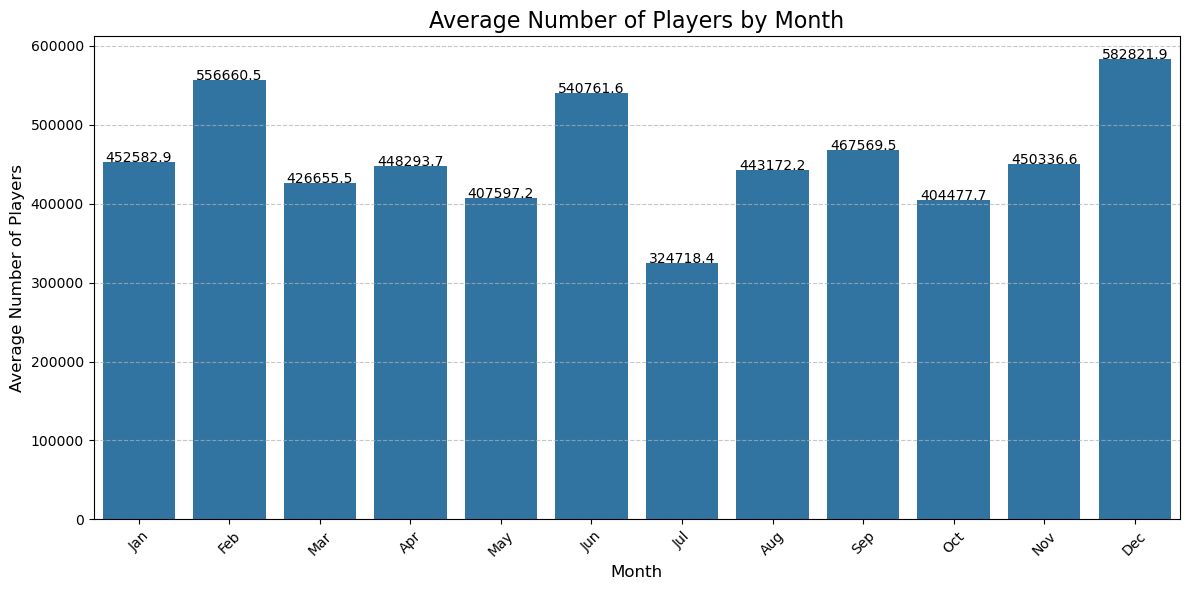

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Calculate the average number of players for each month
monthly_avg = final_df.groupby('month')['players'].mean().reset_index()

# Create a dictionary to map month abbreviations to numbers for proper sorting
month_to_num = {month: i for i, month in enumerate(calendar.month_abbr[1:], 1)}

# Add a numeric month column for sorting
monthly_avg['month_num'] = monthly_avg['month'].map(month_to_num)

# Sort by month number
monthly_avg = monthly_avg.sort_values('month_num')

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='players', data=monthly_avg, order=monthly_avg['month'])

# Customize the plot
plt.title('Average Number of Players by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Number of Players', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, v in enumerate(monthly_avg['players']):
    plt.text(i, v + 0.1, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

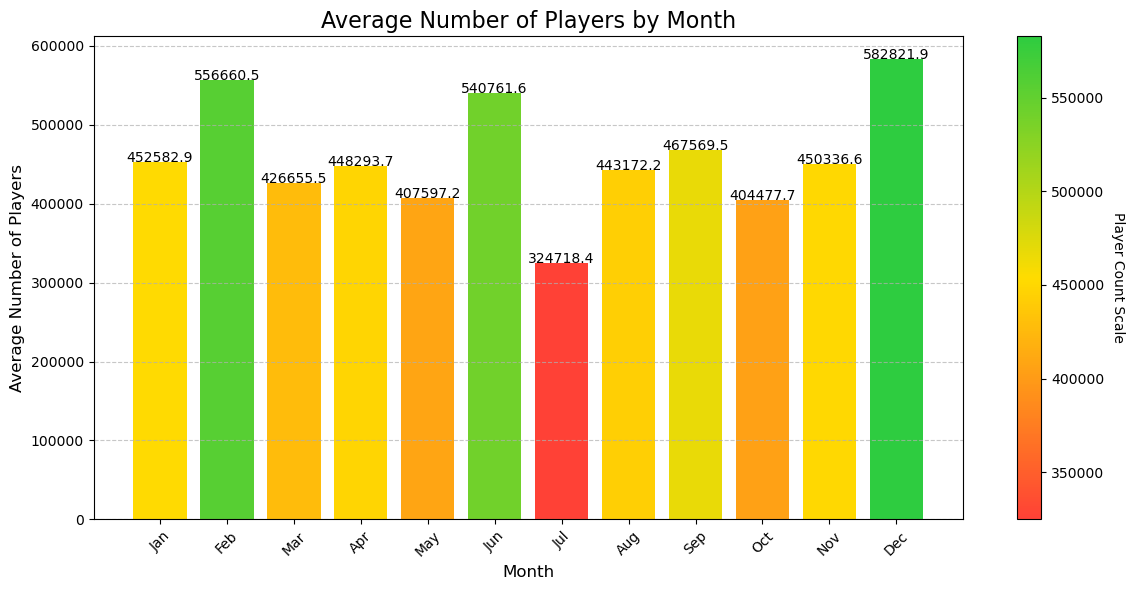

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

monthly_avg = final_df.groupby('month')['players'].mean().reset_index()

# Create a dictionary to map month abbreviations to numbers for proper sorting
month_to_num = {month: i for i, month in enumerate(calendar.month_abbr[1:], 1)}

# Add a numeric month column for sorting
monthly_avg['month_num'] = monthly_avg['month'].map(month_to_num)

# Sort by month number
monthly_avg = monthly_avg.sort_values('month_num')

# Create a custom colormap from red to green
cmap = LinearSegmentedColormap.from_list("RedToGreen", ["#FF4136", "#FFDC00", "#2ECC40"])

# Normalize the player values to use for coloring
norm = plt.Normalize(monthly_avg['players'].min(), monthly_avg['players'].max())
colors = [cmap(norm(value)) for value in monthly_avg['players']]

# Create the bar plot with custom colors
fig, ax = plt.subplots(figsize=(12, 6))  # Create figure and axes objects explicitly
bars = ax.bar(monthly_avg['month'], monthly_avg['players'], color=colors)  # Use ax instead of plt

# Customize the plot
ax.set_title('Average Number of Players by Month', fontsize=16)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Average Number of Players', fontsize=12)
plt.xticks(rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, v in enumerate(monthly_avg['players']):
    ax.text(i, v + 0.1, f'{v:.1f}', ha='center')

# Add a color bar to show the scale
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)  # Pass the ax argument to colorbar
cbar.set_label('Player Count Scale', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

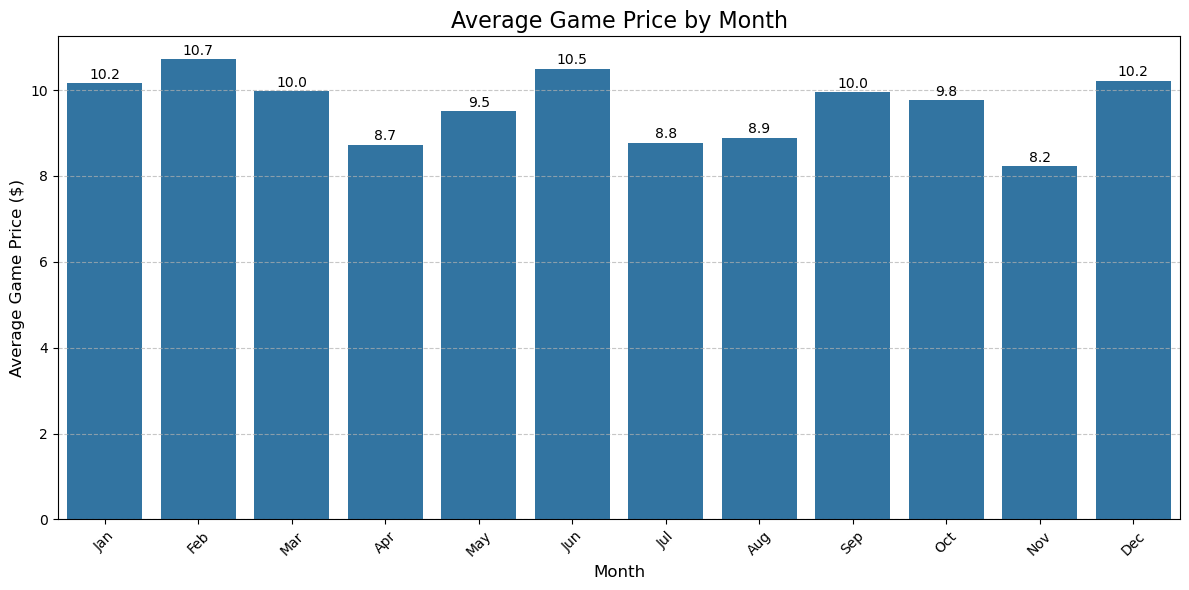

In [18]:
# Calculate the average number of players for each month
monthly_avg = final_df.groupby('month')['price'].mean().reset_index()

# Create a dictionary to map month abbreviations to numbers for proper sorting
month_to_num = {month: i for i, month in enumerate(calendar.month_abbr[1:], 1)}

# Add a numeric month column for sorting
monthly_avg['month_num'] = monthly_avg['month'].map(month_to_num)

# Sort by month number
monthly_avg = monthly_avg.sort_values('month_num')

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='price', data=monthly_avg, order=monthly_avg['month'])

# Customize the plot
plt.title('Average Game Price by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Game Price ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for i, v in enumerate(monthly_avg['price']):
    plt.text(i, v + 0.1, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()